# 07 - Model Training and Comparison

## Electricity Consumption Forecasting

### Objective

Train several machine-learning regression models to predict **next-hour electricity consumption**.

We will compare the models against the simple previous-hour baseline created in Notebook 06.

### Models

1. Linear Regression — simple and interpretable baseline ML model
2. Random Forest Regressor — nonlinear tree ensemble
3. HistGradientBoosting Regressor — efficient boosting model

The test set will remain completely unseen during model training.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 2. Load Training and Testing Data


In [2]:
train_path = "../data/processed/train_dataset.csv"
test_path = "../data/processed/test_dataset.csv"

train_df = pd.read_csv(train_path, parse_dates=["DateTime"])
test_df = pd.read_csv(test_path, parse_dates=["DateTime"])

train_df = train_df.set_index("DateTime").sort_index()
test_df = test_df.set_index("DateTime").sort_index()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTesting period:")
print(test_df.index.min(), "to", test_df.index.max())


Training shape: (19532, 12)
Testing shape: (4883, 12)

Training period:
2006-12-23 17:00:00 to 2009-03-16 12:00:00

Testing period:
2009-03-16 13:00:00 to 2009-10-05 23:00:00


## 3. Define Features and Target


In [3]:
feature_columns = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1h",
    "Lag_24h",
    "Lag_168h",
    "Rolling_24h",
    "Rolling_168h"
]

target_column = "Target_Next_Hour"

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (19532, 10)
y_train: (19532,)
X_test : (4883, 10)
y_test : (4883,)


## 4. Verify There Are No Missing Values


In [4]:
print("Training missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())
print("Training target missing values:", y_train.isnull().sum())
print("Testing target missing values:", y_test.isnull().sum())


Training missing values: 0
Testing missing values: 0
Training target missing values: 0
Testing target missing values: 0


## 5. Define the Models

### Linear Regression
Provides an interpretable linear relationship between the engineered features and electricity consumption.

### Random Forest
Can capture nonlinear relationships and interactions between time and historical-consumption features.

### HistGradientBoosting
Builds trees sequentially, with each new tree improving previous errors. It is often strong on structured/tabular data.


In [5]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

print("Models:")
for name in models:
    print("-", name)


Models:
- Linear Regression
- Random Forest
- HistGradientBoosting


## 6. Train the Models

The models are fitted **only on the training period**.

The test period is not used for fitting or model selection.


In [6]:
trained_models = {}
predictions = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

print("Training completed.")


Training Linear Regression...


Training Random Forest...
Training HistGradientBoosting...
Training completed.


## 7. Compare Model Performance

### Metrics

- **MAE**: average absolute prediction error. Lower is better.
- **RMSE**: penalizes large errors more strongly. Lower is better.
- **R²**: proportion of target variation explained by the model. Higher is better.

The baseline from Notebook 06 will also be included for comparison.


In [7]:
baseline_predictions = X_test["Lag_1h"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

results.append({
    "Model": "Previous-Hour Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2
0,HistGradientBoosting,0.374329,0.518418,0.455438
1,Random Forest,0.387896,0.533059,0.424245
2,Linear Regression,0.466991,0.618019,0.226089
3,Previous-Hour Baseline,0.534101,0.795210,-0.281300


## 8. Identify the Best Model

For this project, we primarily select the model with the **lowest MAE**, while also considering RMSE and R².

Do not select a model using the test set repeatedly during tuning. The test set is our final unseen evaluation period.


In [8]:
best_model_name = (
    results_df[results_df["Model"] != "Previous-Hour Baseline"]
    .sort_values("MAE")
    .iloc[0]["Model"]
)

print("Best ML model based on MAE:", best_model_name)


Best ML model based on MAE: HistGradientBoosting


## 9. Plot Actual vs Predicted Values

To keep the visualization readable, we plot a limited portion of the test period.

The plot helps us visually compare the best model's predictions with actual electricity consumption.


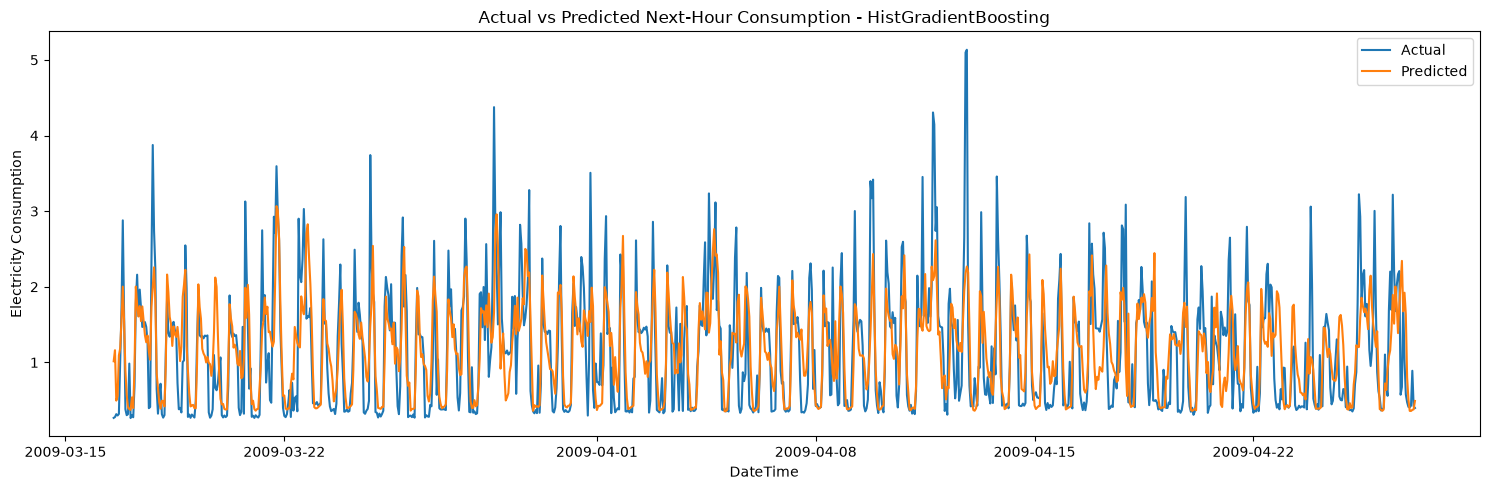

In [9]:
best_predictions = predictions[best_model_name]

plot_points = min(1000, len(y_test))

plt.figure(figsize=(15, 5))
plt.plot(
    y_test.index[:plot_points],
    y_test.iloc[:plot_points].values,
    label="Actual"
)
plt.plot(
    y_test.index[:plot_points],
    best_predictions[:plot_points],
    label="Predicted"
)

plt.title(f"Actual vs Predicted Next-Hour Consumption - {best_model_name}")
plt.xlabel("DateTime")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Residual Analysis

A residual is:

**Actual - Predicted**

Large residuals indicate observations where the model struggled.

We inspect the residual distribution for the best model.


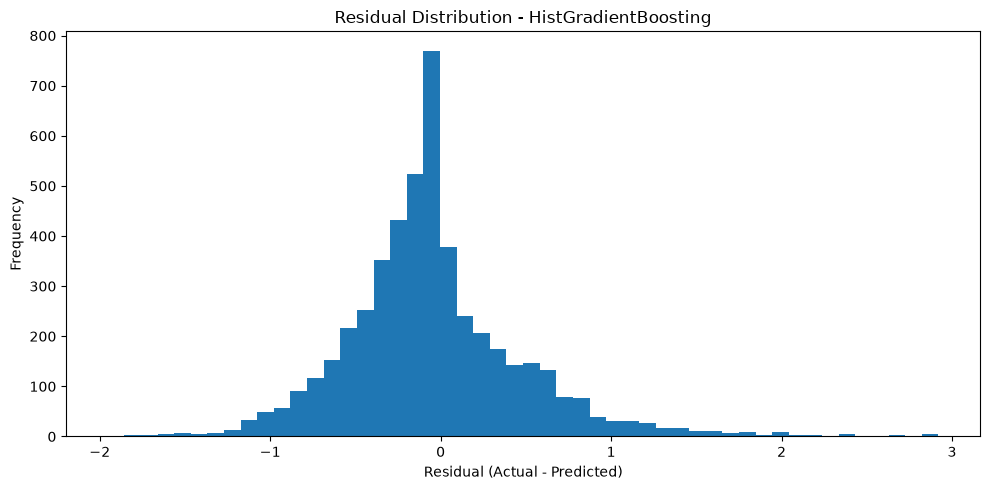

Mean residual: -0.046516790082531984
Mean absolute residual: 0.374329406315359


In [10]:
best_residuals = y_test.values - best_predictions

plt.figure(figsize=(10, 5))
plt.hist(best_residuals, bins=50)
plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean residual:", np.mean(best_residuals))
print("Mean absolute residual:", np.mean(np.abs(best_residuals)))


## 11. Plot Prediction Error Over Time


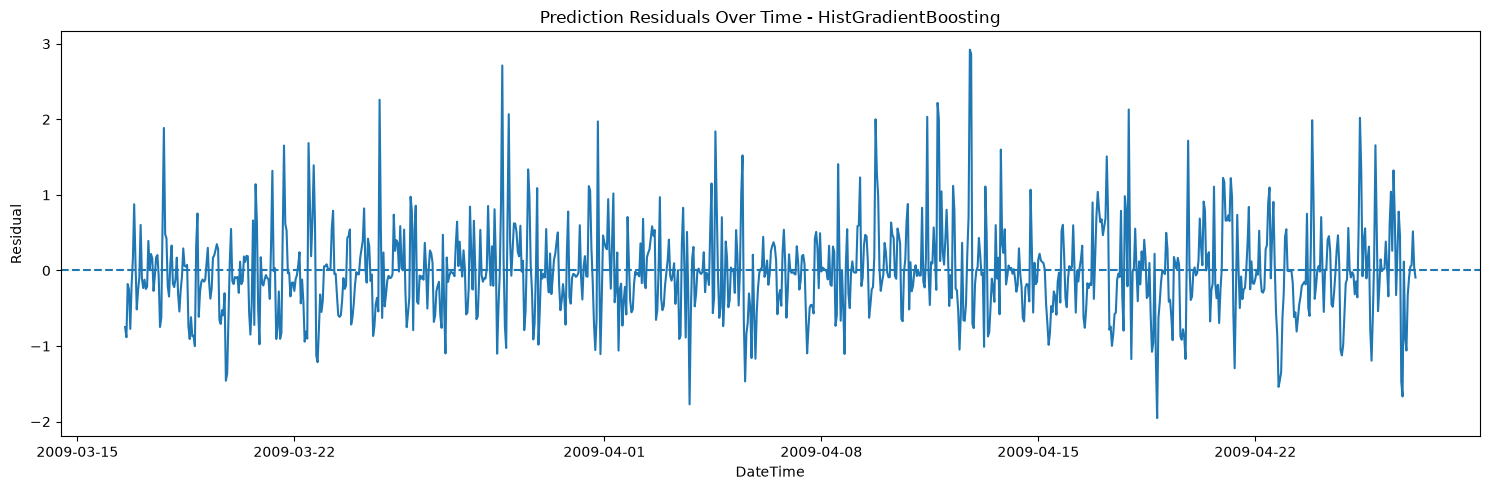

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(
    y_test.index[:plot_points],
    best_residuals[:plot_points]
)
plt.axhline(0, linestyle="--")
plt.title(f"Prediction Residuals Over Time - {best_model_name}")
plt.xlabel("DateTime")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 12. Feature Importance for Tree Models

Tree-based models can provide feature importance values.

We inspect these values for Random Forest and HistGradientBoosting where supported.

The purpose is to understand which historical and calendar features contribute most to predictions.


In [12]:
for model_name in ["Random Forest", "HistGradientBoosting"]:
    model = trained_models[model_name]

    if hasattr(model, "feature_importances_"):
        importance = pd.Series(
            model.feature_importances_,
            index=feature_columns
        ).sort_values(ascending=False)

        print(f"\n{model_name} feature importance:")
        display(importance.to_frame("Importance"))



Random Forest feature importance:


,Importance
Lag_1h,0.302309
Hour,0.232311
Rolling_24h,0.112716
Rolling_168h,0.100614
Lag_168h,0.092507
Lag_24h,0.079321
DayOfWeek,0.036789
Month,0.027601
IsWeekend,0.009748
Quarter,0.006083


## 13. Save Model Comparison Results


In [13]:
results_path = "../data/processed/model_comparison_results.csv"

results_df.to_csv(results_path, index=False)

print("Results saved to:", results_path)


Results saved to: ../data/processed/model_comparison_results.csv


## 14. Save the Best Model

The best model is selected using the lowest MAE among the machine-learning models.

The model is saved so that a later notebook or dashboard can load it without retraining.


In [14]:
import joblib

model_path = "../models/best_electricity_forecasting_model.joblib"

joblib.dump(
    trained_models[best_model_name],
    model_path
)

print("Best model:", best_model_name)
print("Saved to:", model_path)


Best model: HistGradientBoosting
Saved to: ../models/best_electricity_forecasting_model.joblib


## 15. Final Validation


In [15]:
print("===== MODEL TRAINING SUMMARY =====")
print("\nModel comparison:")
display(results_df)

print("\nBest ML model:", best_model_name)

best_row = results_df[results_df["Model"] == best_model_name].iloc[0]

print("\nBest model metrics:")
print("MAE :", best_row["MAE"])
print("RMSE:", best_row["RMSE"])
print("R²  :", best_row["R2"])

print("\nBaseline metrics:")
baseline_row = results_df[results_df["Model"] == "Previous-Hour Baseline"].iloc[0]
print("MAE :", baseline_row["MAE"])
print("RMSE:", baseline_row["RMSE"])
print("R²  :", baseline_row["R2"])


===== MODEL TRAINING SUMMARY =====

Model comparison:


,Model,MAE,RMSE,R2
0,HistGradientBoosting,0.374329,0.518418,0.455438
1,Random Forest,0.387896,0.533059,0.424245
2,Linear Regression,0.466991,0.618019,0.226089
3,Previous-Hour Baseline,0.534101,0.795210,-0.281300



Best ML model: HistGradientBoosting

Best model metrics:
MAE : 0.374329406315359
RMSE: 0.5184178276691596
R²  : 0.45543829902335753

Baseline metrics:
MAE : 0.534100681393319
RMSE: 0.7952098232328327
R²  : -0.2812996599045363


## Conclusion

The first set of forecasting models has been trained and compared against the previous-hour baseline.

### Next notebook

**08 - Model Evaluation**

We will perform a more detailed evaluation of the selected model, including:

- MAE, RMSE and R²
- Actual vs predicted analysis
- Error by hour
- Error by weekday
- Error by month
- Peak-demand prediction performance
- A final model recommendation for the project.
